In [79]:
import optuna
from optuna.trial import TrialState
from optuna.storages import JournalStorage, JournalFileStorage
import pandas as pd
import glob
import matplotlib.pyplot as plt
import os
import seaborn as sns
import csv

In [46]:
general_output_directory = "C:\\ResearchWork\\Matsim_integration\\HPC\\RL_Mode_Choice\\decenteralize_training\\scenarios\\sioux-falls\\copied_output"
output_folder = "run_13June"

output_directory = os.path.join(general_output_directory, output_folder)

log_database_directory = os.path.join(output_directory, "optimization_logs")
result_database_directory = os.path.join(output_directory, "results")

#storage_file_name = "optimization_corrected.log"
#study_name = "matsim_optimization"
storage_file_name = "optimization_migrated_trials.log"
study_name = "matsim_mode_choice_optimization"

storage_file_path = os.path.join(log_database_directory, storage_file_name)

file_storage = JournalFileStorage(storage_file_path)
storage_engine = JournalStorage(file_storage)

study = optuna.load_study(study_name=study_name, storage=storage_engine)

C:\Users\akappadia\AppData\Local\Temp\ipykernel_17196\2142269373.py:16: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  file_storage = JournalFileStorage(storage_file_path)


In [47]:
all_trials = study.trials
total_trials = len(all_trials)

completed_trials = [t for t in all_trials if t.state == TrialState.COMPLETE]
failed_trials = [t for t in all_trials if t.state == TrialState.FAIL]
pruned_trials = [t for t in all_trials if t.state == TrialState.PRUNED]
running_trials = [t for t in all_trials if t.state == TrialState.RUNNING]

print("========================================")
print("       OPTUNA STUDY OVERVIEW            ")
print("========================================")
print(f"Total Trials Generated:         {total_trials}")
print(f"Successfully Completed:         {len(completed_trials)}")
print(f"Timed-out / Unfinished:         {len(running_trials)}")
print(f"Explicitly Failed:              {len(failed_trials)}")
print(f"Pruned (Stopped Early):         {len(pruned_trials)}")
print("========================================\n")

       OPTUNA STUDY OVERVIEW            
Total Trials Generated:         596
Successfully Completed:         596
Timed-out / Unfinished:         0
Explicitly Failed:              0
Pruned (Stopped Early):         0



In [48]:
print("\n" + "="*50)
print("🔍 DIRECT DATABASE LOOKUP FOR TRIAL #346")
print("="*50)
    
try:
    # Reload the fresh study directly from storage to see what was written
    verify_study = optuna.load_study(study_name=study_name, storage=storage_engine)
        
    # Pull trial 346 directly out of the database array
    target_record = [t for t in verify_study.trials if t.number == 342][0]
        
    print(f"Actual Saved Trial Number: {target_record.number}")
    print(f"Actual Saved Values in DB:  {target_record.values}")
    print(f"Matches Pareto Front?      {target_record.number in [b.number for b in verify_study.best_trials]}")
except IndexError:
    print("Trial #346 was not found in the new database!")
except Exception as e:
    print(f"Verification error: {e}")
print("="*50 + "\n")


🔍 DIRECT DATABASE LOOKUP FOR TRIAL #346
Actual Saved Trial Number: 342
Actual Saved Values in DB:  [168.83988956175477, 6.794677477555143, 255.0]
Matches Pareto Front?      False



In [49]:
print("--- BEST TRIALS (PARETO FRONT) ---")
best_trials = study.best_trials

print(f"Found {len(best_trials)} Pareto-optimal trials.\n")

for i, trial in enumerate(best_trials):
    print(f"--- Trial #{trial.number} ---")
    print(f"  Objective Scores: {trial.values}") 
    print("  Hyperparameters:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    print("-" * 30)


--- BEST TRIALS (PARETO FRONT) ---
Found 31 Pareto-optimal trials.

--- Trial #2 ---
  Objective Scores: [279.4674403715652, 1.0189734444288214, 240.0]
  Hyperparameters:
    alpha: 0.2457613733410785
    gamma: 0.9169115671491672
    epsilon_decay: 0.9526758339256258
    epsilon_minimum: 0.001968316101082197
    discontinuity: 2.838176064737516
    retrieval_cost: 3.0147638510723516
------------------------------
--- Trial #22 ---
  Objective Scores: [287.93362123300136, 0.3098225405735741, 782.0]
  Hyperparameters:
    alpha: 0.07776017304423205
    gamma: 0.8943309595284245
    epsilon_decay: 0.9539154824950122
    epsilon_minimum: 0.014985716449780567
    discontinuity: 1.2520829136870462
    retrieval_cost: 2.2483847017823466
------------------------------
--- Trial #48 ---
  Objective Scores: [259.1341823973665, 0.5164118569760416, 321.0]
  Hyperparameters:
    alpha: 0.1748096779055491
    gamma: 0.8555968733503105
    epsilon_decay: 0.9359879233530278
    epsilon_minimum: 0.012

In [50]:
if len(best_trials) > 0:
    records = []
    for trial in best_trials:
        # Create the base row with Trial Number and your 3 distinct objectives
        if trial.number == 1:
            trail_number = trial.number + 2
        else:
            trail_number = trial.number + 4
        row = {
            "Trial_Number": trial.number + 4,
            "Settled_Reward (Maximize)": trial.values[0],
            "Variance_Distance (Minimize)": trial.values[1],
            "Saturation_Iteration (Minimize)": trial.values[2]
        }
        
        # Dynamically append all hyperparameters evaluated in this trial
        for param_name, param_val in trial.params.items():
            row[param_name] = param_val
            
        records.append(row)

    # Convert the list of dictionaries into a Pandas DataFrame
    df_pareto = pd.DataFrame(records)

    # Sort sequentially by trial number for clean viewing
    df_pareto = df_pareto.sort_values(by="Trial_Number").reset_index(drop=True)

In [51]:
def normalize_series(series):
    denominator = series.max() - series.min()
    if denominator == 0:
        return series * 0.0  # Avoid division by zero if all values are identical
    return (series - series.min()) / denominator

In [52]:
def compute_lagrangian_priority_score(data_frame, weights):
    """
    Computes a normalized Lagrangian-style scalar score based on the weights array
    
    Appends the final 'Lagrangian_Loss' to the dataframe.
    """
    # Create a copy to prevent modifying the original dataframe destructively
    df = data_frame.copy()
    
    # 1. Extract raw objective columns (Update these strings to match your exact DF column names)
    raw_reward = df["Settled_Reward (Maximize)"]
    raw_variance = df["Variance_Distance (Minimize)"]
    raw_saturation = df["Saturation_Iteration (Minimize)"]

    normalize_saturation = normalize_series(raw_saturation)
    normalize_variance = normalize_series(raw_variance)
    normalize_reward = normalize_series(raw_reward)
    
    # 3. Compute Lagrangian Loss Component
    # We use (1.0 - normalize_reward) because maximizing reward is equivalent to minimizing its complement
    df["Lagrangian_Loss"] = (weights[0] * normalize_saturation) + (weights[1] * normalize_variance) + (weights[2] * (1.0 - normalize_reward))
    
    # 4. Sort the DataFrame so the absolute best trials (lowest loss) appear at the top
    df = df.sort_values(by="Lagrangian_Loss", ascending=True).reset_index(drop=True)
    
    return df

In [53]:
def plot_reward_curves(data_frame, data_directory, window_size, y_zoom=None, x_zoom=None, save_figure=False):
    """
    Plots the moving average reward curves across trials.
    Set x_zoom or y_zoom to None (or leave blank) to turn off zoom and auto-scale.
    """
    if save_figure:
        OUTPUT_PLOT_PATH = os.path.join(data_directory, "all_trials_moving_average.png")
    
    WINDOW_SIZE = window_size
    valid_trial_numbers = set(data_frame["Trial_Number"])
    trial_folders = glob.glob(os.path.join(data_directory, "trial_*"))

    if trial_folders:
        plt.figure(figsize=(13, 8))  # Expanded slightly to make room for the legend
        trials_processed = 0
        
        trial_folders.sort(key=lambda x: int(os.path.basename(x).split('_')[1]))

        palette = sns.color_palette("hsv", data_frame["Trial_Number"].nunique())
        
        for folder in trial_folders:
            folder_name = os.path.basename(folder)
            trial_number = int(folder_name.split('_')[1])
            
            if trial_number not in valid_trial_numbers:
                continue
                
            csv_path = os.path.join(folder, "agent_tracking.csv")
            if not os.path.exists(csv_path):
                continue
                
            try:
                df = pd.read_csv(csv_path)
                utility_series = df.iloc[:, 3] 
                moving_avg = utility_series.rolling(window=WINDOW_SIZE, min_periods=1).mean()
                
                plt.plot(moving_avg, label=f"Trial #{trial_number}", color=palette[trials_processed], alpha=0.6, linewidth=1.5)
                trials_processed += 1
                
            except Exception:
                continue

        if trials_processed > 0:

            if y_zoom is not None and len(y_zoom) == 2:
                plt.ylim(y_zoom[0], y_zoom[1])
                
            if x_zoom is not None and len(x_zoom) == 2:
                plt.xlim(x_zoom[0], x_zoom[1])
            
            # Setup labels and clean layout
            plt.title(f"Training Behavior of RL Agent (Window Size = {WINDOW_SIZE})", fontsize=14, fontweight='bold')
            plt.xlabel("Simulation Iteration", fontsize=12)
            plt.ylabel("Reward (Moving Average)", fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.5)
            
            plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., fontsize=9, ncol=2 if trials_processed > 20 else 1)
            plt.tight_layout() # Ensures everything fits on your monitor cleanly

            plt.show()

            if save_figure:
                plt.savefig(OUTPUT_PLOT_PATH, dpi=300, bbox_inches='tight')
                print(f"Plot successfully saved to: {OUTPUT_PLOT_PATH}")

In [83]:
def plot_convergence_speed(dataframe, directory, threshold_pct=0.95, stability_window=50):
    """
    Finds the CSV file for each trial, extracts the raw rewards, and calculates 
    the first iteration where performance locks in above 95% of peak.
    """
    trial_names = []
    convergence_steps = []
    base_dir = directory
    
    for _, row in dataframe.iterrows():
        trial_num = int(row["Trial_Number"])
        name = f"Trial #{trial_num}"
        
        csv_file_path = os.path.join(base_dir, f"trial_{trial_num}", "agent_tracking.csv")
        if not os.path.exists(csv_file_path):
            continue
            
        rewards = []
        with open(csv_file_path, mode="r", encoding="utf-8") as f:
            reader = csv.reader(f)
            next(reader)  # Skip header
            for csv_row in reader:
                if csv_row:
                    rewards.append(float(csv_row[3]))
        
        if len(rewards) == 0:
            continue
            
        peak_reward = max(rewards)
        # Handle scaling threshold carefully
        target = peak_reward * threshold_pct if peak_reward > 0 else peak_reward * (2 - threshold_pct)
        
        # FORWARD SCAN: Find where it crosses and stays above the target
        conv_idx = len(rewards)  # Default if it never stays stable
        
        for i in range(len(rewards) - stability_window):
            # Check if the next 'stability_window' iterations are all above the target
            if all(val >= target for val in rewards[i:i + stability_window]):
                conv_idx = i
                break
                
        trial_names.append(name)
        convergence_steps.append(conv_idx)
        
    # Plotting code
    plt.figure(figsize=(10, 6))
    bars = plt.bar(trial_names, convergence_steps, color='#5499c7', edgecolor='grey', width=0.6)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f"{int(yval)} iter", 
                 ha='center', va='bottom', fontweight='bold')
        
    plt.title(f"True Training Efficiency: Iterations to Stabilize Above {int(threshold_pct*100)}% Peak", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Simulation Iteration to Converge", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [87]:
def plot_early_stage_volatility(dataframe, directory, max_iterations=150):
    flat_data = []
    base_dir = directory
    
    for _, row in dataframe.iterrows():
        trial_num = int(row["Trial_Number"])
        name = f"Trial #{trial_num}"
        
        csv_file_path = os.path.join(base_dir, f"trial_{trial_num}", "agent_tracking.csv")
        if not os.path.exists(csv_file_path):
            continue
            
        rewards = []
        with open(csv_file_path, mode="r", encoding="utf-8") as f:
            reader = csv.reader(f)
            next(reader)
            for csv_row in reader:
                if csv_row:
                    rewards.append(float(csv_row[3]))
                    
        early_slice = rewards[:min(max_iterations, len(rewards))]
        for val in early_slice:
            flat_data.append({"Trial": name, "Reward": val})
            
    df_long = pd.DataFrame(flat_data)
    
    plt.figure(figsize=(11, 6))
    sns.boxplot(x="Trial", y="Reward", data=df_long, palette="Set2", width=0.5)
    
    plt.title(f"Early-Stage Learning Stability (First {max_iterations} Iterations)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Hyperparameter Configuration", fontsize=12)
    plt.ylabel("Exploration Reward Distribution ", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [59]:
df_lagrangian = compute_lagrangian_priority_score(df_pareto, [0.3, 0.1, 0.6])

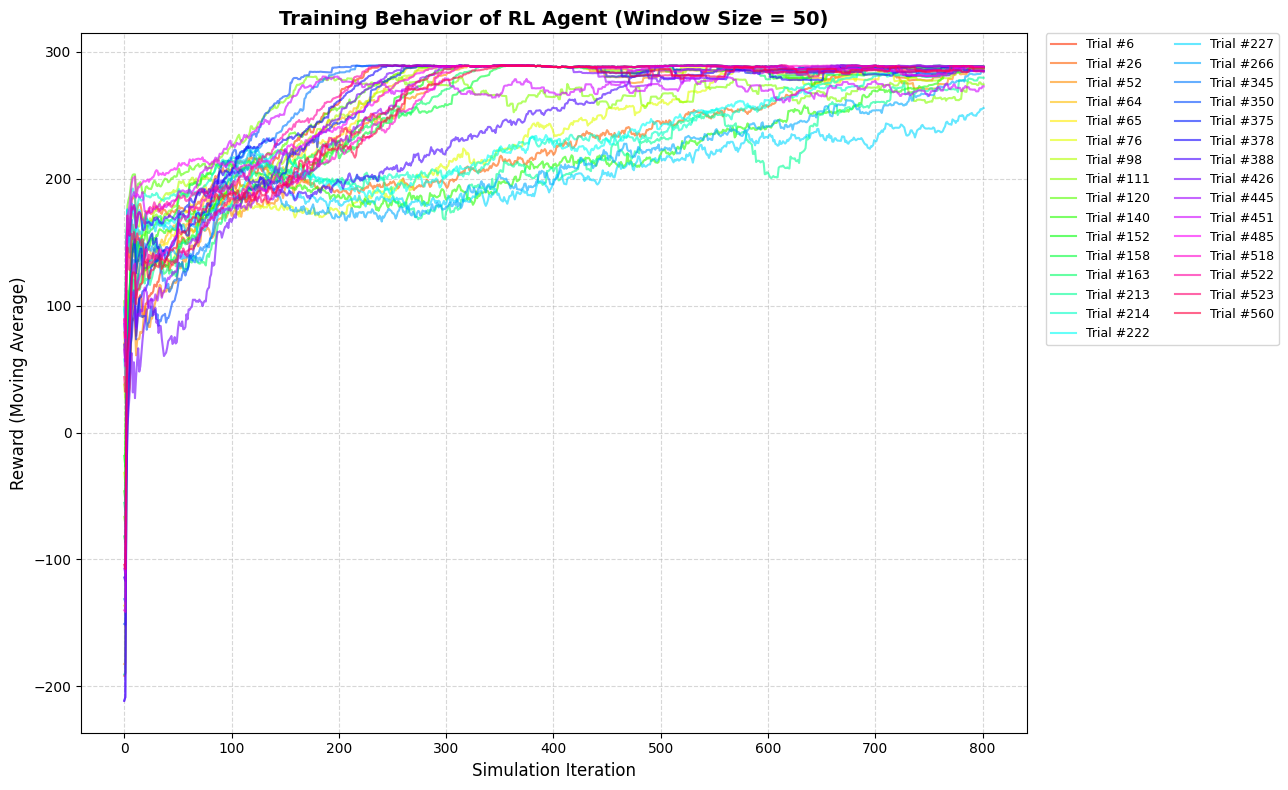

In [55]:
plot_reward_curves(df_pareto, result_database_directory, 50, y_zoom=None, x_zoom=None)

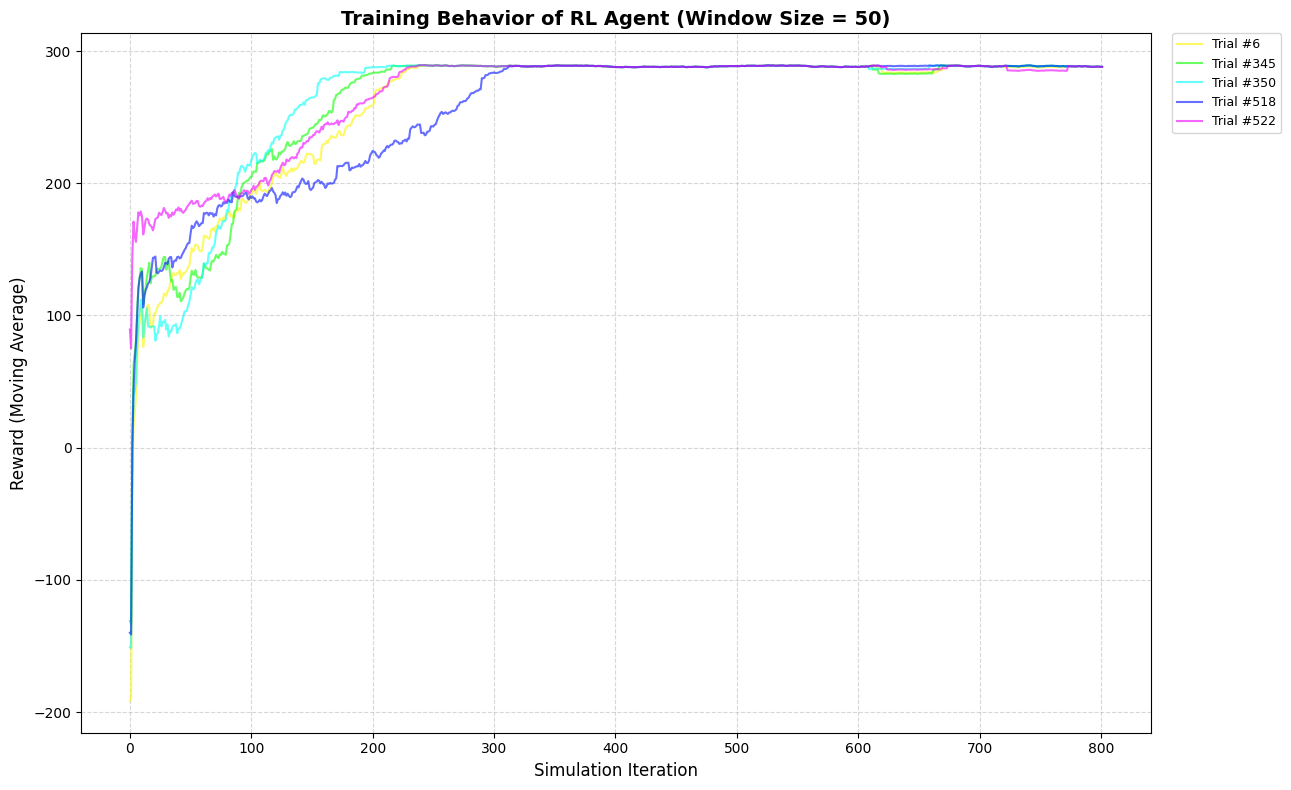

In [56]:
# Select the best trails based on the lagrangian
selected_trials = 5

top_5_trials = df_lagrangian["Trial_Number"].head(selected_trials).tolist()

rows = []
for trial in top_5_trials:
    matched_row = df_lagrangian[df_lagrangian["Trial_Number"] == trial]
    if not matched_row.empty:
        val2 = matched_row.iloc[0, 1]
        val3 = matched_row.iloc[0, 2]
        val4 = matched_row.iloc[0, 3]
        val5 = matched_row.iloc[0, 10]
        rows.append([trial, val2, val3, val4, val5])

df_pareto_reduced = pd.DataFrame(rows, columns=["Trial_Number", "Settled_Reward", "Variance_Distance", "Saturation_Iteration", "Lagrangian"])

plot_reward_curves(df_pareto_reduced, result_database_directory, 50, y_zoom=None, x_zoom=None)

In [74]:
df_pareto_reduced

,Trial_Number,Settled_Reward,Variance_Distance,Saturation_Iteration,Lagrangian
0,350,288.841766,1.548093,214.0,0.051109
1,518,288.964748,0.518068,317.0,0.080095
2,345,279.380322,1.296421,217.0,0.123837
3,6,279.467440,1.018973,240.0,0.128952
4,522,279.171596,1.062442,238.0,0.131180


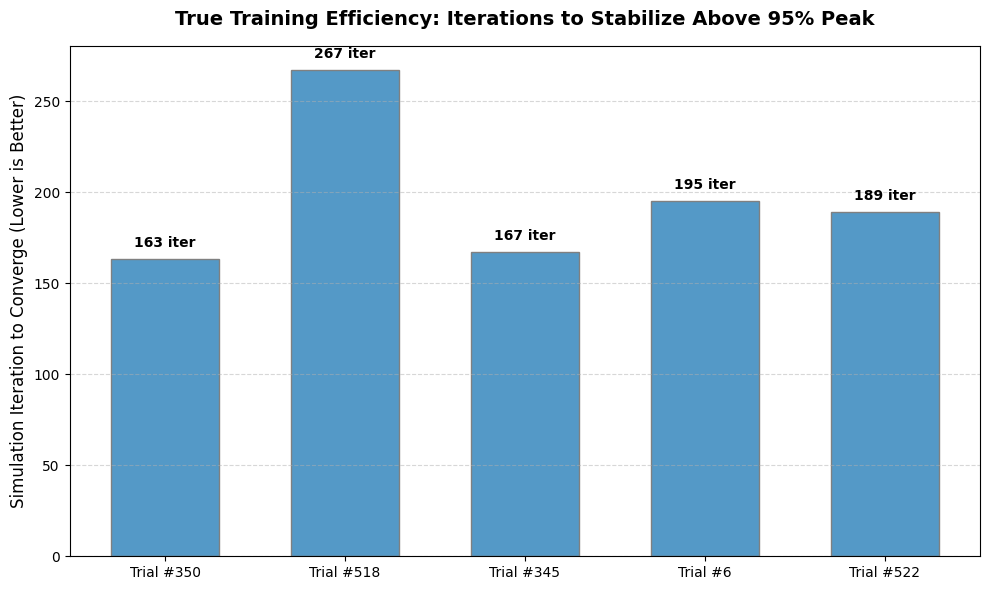

In [82]:
plot_convergence_speed(df_pareto_reduced, result_database_directory)

C:\Users\akappadia\AppData\Local\Temp\ipykernel_17196\1732316990.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Trial", y="Reward", data=df_long, palette="Set2", width=0.5)


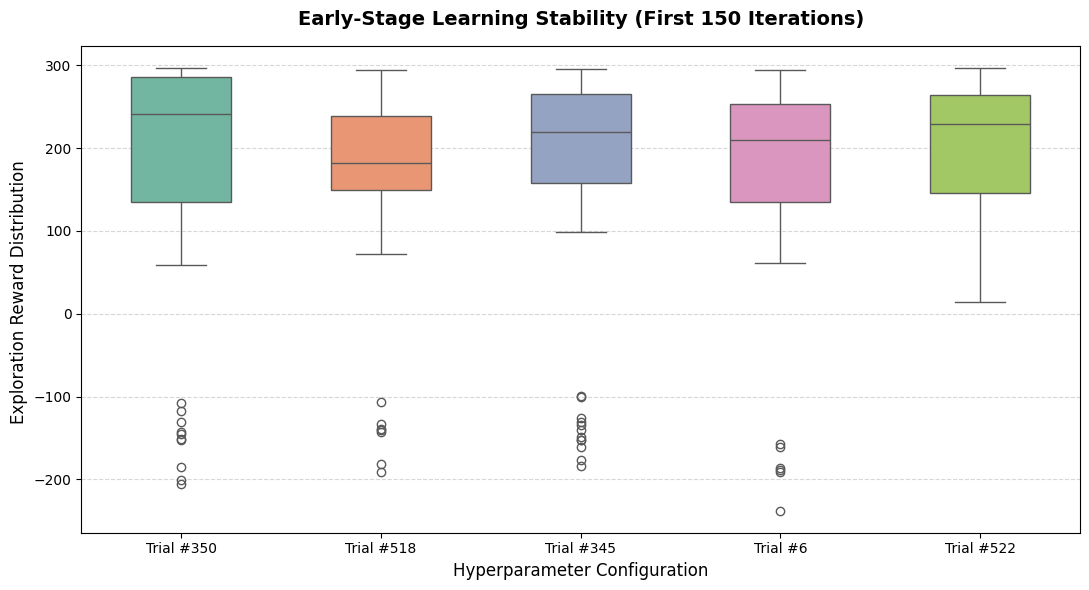

In [ ]:
plot_early_stage_volatility(df_pareto_reduced, result_database_directory)

In [57]:
df_pareto_reduced

,Trial_Number,Settled_Reward,Variance_Distance,Saturation_Iteration,Lagrangian
0,350,288.841766,1.548093,214.0,0.051109
1,518,288.964748,0.518068,317.0,0.080095
2,345,279.380322,1.296421,217.0,0.123837
3,6,279.467440,1.018973,240.0,0.128952
4,522,279.171596,1.062442,238.0,0.131180


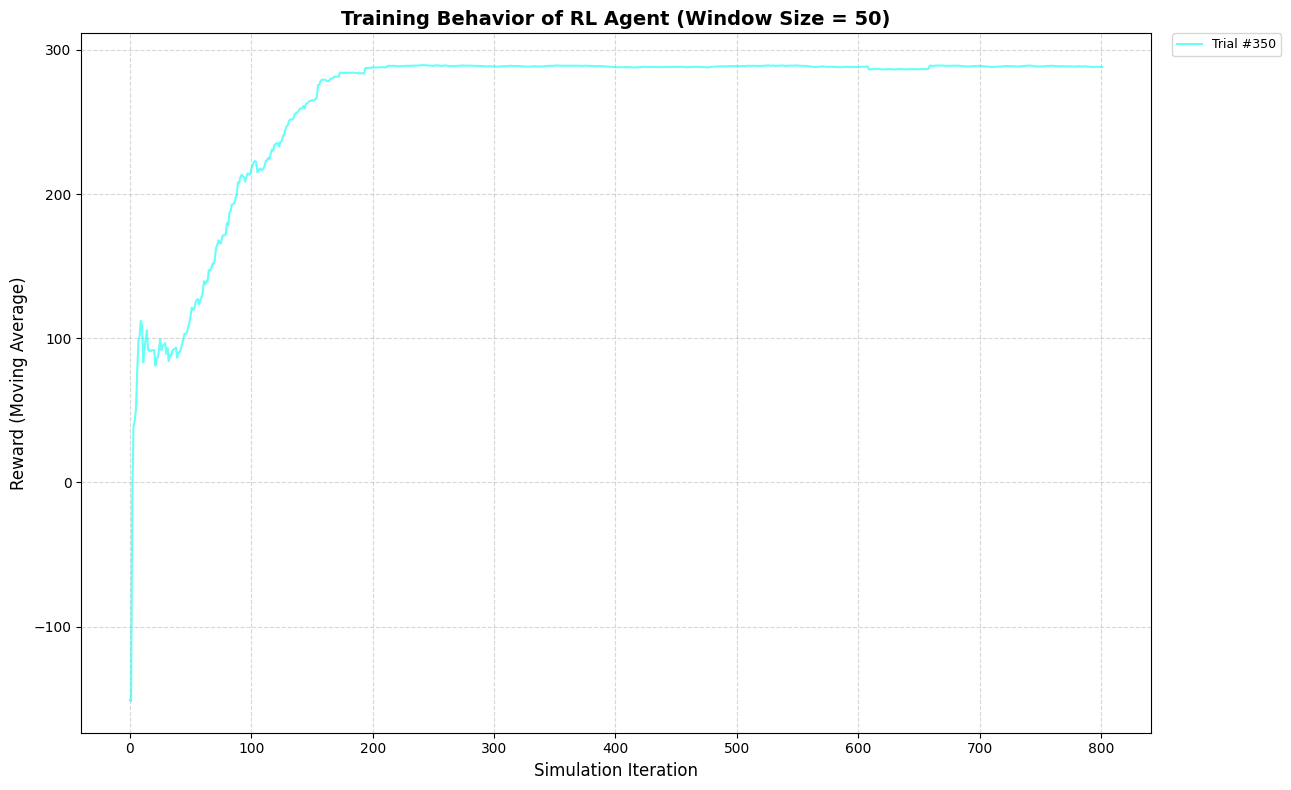

In [58]:
plot_reward_curves(df_pareto_reduced[df_pareto_reduced["Trial_Number"]==350], result_database_directory, 50, y_zoom=None, x_zoom=None)